In [21]:
from __future__ import annotations

import math
from dataclasses import asdict, dataclass
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HULPFUNCTIES

In [22]:
def veilige_del(a: float, b: float, fallback: float = float("nan")) -> float:
    return fallback if abs(b) < 1e-16 else a / b


def rms_waarde(waarden: List[float], tijden_s: List[float]) -> float:
    """RMS-waarde gewogen naar duur van elk segment."""
    x = np.asarray(waarden, dtype=float)
    t = np.asarray(tijden_s, dtype=float)
    if len(x) != len(t) or np.any(t < 0.0) or np.sum(t) <= 0.0:
        return float("nan")
    return float(np.sqrt(np.sum((x**2) * t) / np.sum(t)))


def koppel_uit_axiale_kracht(kracht_N: float, spoed_m: float, rendement: float) -> float:
    if spoed_m <= 0.0 or rendement <= 0.0:
        return float("nan")
    return kracht_N * spoed_m / (2.0 * math.pi * rendement)


def traagheidsmoment_massieve_cilinder(massa_kg: float, diameter_m: float) -> float:
    return 0.5 * massa_kg * (diameter_m / 2.0) ** 2


def massa_massieve_cilinder(
    lengte_m: float, diameter_m: float, rho_kg_m3: float = 7850.0
) -> float:
    return rho_kg_m3 * math.pi * (diameter_m / 2.0) ** 2 * lengte_m


def toon_dataframe(naam: str, df: pd.DataFrame, max_rijen: int = 20) -> None:
    print(f"\n=== {naam.upper()} ===")
    if len(df) > max_rijen:
        print(df.head(max_rijen).to_string(index=False))
        print(f"... ({len(df)} rijen in totaal)")
    else:
        print(df.to_string(index=False))

FALLBACK

In [23]:
try:
    resultaten_interface
except NameError:
    resultaten_interface = {
        "export_voor_volgende_modules": {
            "massa_effectief_op_slede_kg":    120.2,  # Tom v19
            "massa_te_versnellen_door_m1_kg": 131.62972278540101,
        }
    }

try:
    resultaten_spindel
except NameError:
    resultaten_spindel = {
        "export_voor_volgende_modules": {
            "n_bedrijf_rpm":               840.0,
            "F_piek_N":                   1832.0,
            "F_eq_N":                     1707.0,
            "koppel_piek_spindel_Nm":        6.33,
            "vermogen_piek_spindel_kW":      0.557,
            "v_piek_m_s":                    0.28,
            "t_versnellen_s":                0.35,
            "t_constante_snelheid_s":        7.507,
            "t_vertragen_s":                 0.35,
            "spoed_spindel_m":               0.020,
            "rendement_spindel":             0.92,
            "nominale_diameter_spindel_m":   0.040,
            "totale_lengte_spindel_m":       2.478,
            "m1_slag_m":                     2.200,
            "m1_vrije_lengte_m":             2.350,
            "m1_schacht_totaal_m":           2.478,
        }
    }

DATACLASS: KANDIDAATMOTOR

In [24]:
@dataclass(frozen=True)
class KandidaatServoMotor:
    """Specificaties van een servomotor kandidaat."""
    fabrikant:                   str
    part_no:                     str
    naam:                        str

    rated_output_W:              float
    rated_torque_Nm:             float
    continuous_stall_torque_Nm:  float
    peak_torque_Nm:              float
    rated_speed_rpm:             float
    max_speed_rpm:               float
    rotor_inertia_kgm2:          float
    recommended_inertia_ratio_max: float
    massa_kg:                    float
    flange_mm:                   float
    radial_load_operating_N:     float
    thrust_load_operating_N:     float
    shaft_diameter_mm:           float
    body_diameter_mm:            float
    body_length_mm:              float

    holding_brake:               bool  = False
    protection_class:            str   = ""
    shaft_type:                  str   = ""

DATACLASS: AANDRIJFCONFIGURATIE

In [25]:
@dataclass(frozen=True)
class ConfiguratieMotorOverbrenging:
    """
    Transmissie-parameters en motorklasse-eisen.
    Waarden zijn afgestemd op Panasonic MSMF082 klasse (750W, 130mm flens, MINAS A7).
    Motortype MSMF082L1U2M: 27-bit absolute encoder, compatibel met MCDN205BE sturing.

    Overbrengingsverhouding i=3 geeft:
        n_spindel,max = 840 rpm → n_motor,max = 2 520 rpm
        T_spindel,piek ≈ 6.33 Nm → T_motor,piek ≈ 2.22 Nm (excl. rotortraagheid)
    """
    naam_motor:                str   = "Panasonic MSMF082L1U2M (MINAS A7, 750 W)"  # Tom v19 update

    # Overbrenging
    overbrengingsverhouding:   float = 3.0
    rendement_overbrenging:    float = 0.95
    J_overbrenging_kgm2:       float = 0.0    # koppelingsschotel/riem verwaarloosbaar

    # Motor-klasse-eisen (drempelwaarden voor ConfiguratieMotorOverbrenging.verifieer)
    n_max_motor_rpm:           float = 5000.0  # max snelheid kandidaat
    continu_koppel_motor_Nm:   float =   2.9   # continuous stall (MSMF082, A7)
    piek_koppel_motor_Nm:      float =   7.16  # peak (MSMF082, A7)
    J_motor_kgm2:              float = 2.48e-4 # rotor J (MSMF082, A7)

    # Marges op eisen
    marge_toerental_motor:     float = 1.10
    marge_koppel_motor:        float = 1.20

    # Materiaal spindel
    rho_spindel_kg_m3:         float = 7850.0

    # Stilstandsduur per cyclus (wachttijd)
    stilstand_s:               float = 0.0

MOTORSEGMENTEN

In [26]:
def bereken_motorsegmenten(
    massa_te_versnellen_kg: float,
    cfg: ConfiguratieMotorOverbrenging,
    spindel_export: Dict[str, float],
) -> Tuple[Dict[str, float], pd.DataFrame]:
    """
    Berekent koppel, toerental en vermogen per bewegingssegment.

    Traagheidstermen:
        J_lineair  = m × (spoed / 2π)²         [lineaire massa teruggevoerd naar spindelas]
        J_spindel  = ½ × m_sp × (d_sp/2)²      [spindel als massieve cilinder]
        J_motor    = cfg.J_motor_kgm2           [rotor, inclusief overbrengingscomponenten]
        J_tot_sp   = J_lineair + J_spindel
        J_mot_ref  = J_tot_sp / i²              [teruggevoerd naar motoras]

    Koppelcontributie:
        T_last     = F_axiaal × spoed / (2π × η_sp)     [lastkoppel]
        T_traagheid_sp = J_tot_sp × α_sp               [inertia-koppel spindelzijde]
        T_sp_totaal   = T_last + T_traagheid_sp
        T_motor_last  = T_sp_totaal / (η_ovbr × i)      [teruggevoerd naar motor]
        T_motor_rotor = J_motor × α_motor               [eigen rotor-inertia]
        T_motor_tot   = T_motor_last + T_motor_rotor
    """
    spoed_m  = spindel_export["spoed_spindel_m"]
    η_sp     = spindel_export["rendement_spindel"]
    v_piek   = spindel_export["v_piek_m_s"]

    t_acc    = spindel_export["t_versnellen_s"]
    t_cte    = spindel_export["t_constante_snelheid_s"]
    t_dec    = spindel_export["t_vertragen_s"]

    d_sp     = spindel_export["nominale_diameter_spindel_m"]
    L_sp     = spindel_export["totale_lengte_spindel_m"]

    i        = cfg.overbrengingsverhouding
    η_ovbr   = cfg.rendement_overbrenging

    a_lin    = v_piek / t_acc if t_acc > 0.0 else 0.0

    # ── Traagheidsberekening ────────────────────────────────────────────────
    m_spindel  = massa_massieve_cilinder(L_sp, d_sp, cfg.rho_spindel_kg_m3)
    J_sp       = traagheidsmoment_massieve_cilinder(m_spindel, d_sp)
    J_lin      = massa_te_versnellen_kg * (spoed_m / (2.0 * math.pi)) ** 2
    J_sp_tot   = J_sp + J_lin
    J_mot_ref  = J_sp_tot / (i**2)
    J_rotor    = cfg.J_motor_kgm2

    omega_sp_max = 2.0 * math.pi * v_piek / spoed_m
    omega_m_max  = i * omega_sp_max
    alpha_sp_acc = 2.0 * math.pi * a_lin / spoed_m
    alpha_m_acc  = i * alpha_sp_acc

    inertia_ratio = veilige_del(J_mot_ref, J_rotor)

    # ── Segmenten ───────────────────────────────────────────────────────────
    F_piek = spindel_export["F_piek_N"]
    F_cte  = spindel_export["F_eq_N"]

    segmenten = [
        {"segment": "versnellen",         "tijd_s": t_acc, "a_lin": +a_lin,  "F": F_piek, "ω": 0.5 * omega_m_max},
        {"segment": "constant",           "tijd_s": t_cte, "a_lin":  0.0,    "F": F_cte,  "ω": omega_m_max},
        {"segment": "vertragen",          "tijd_s": t_dec, "a_lin": -a_lin,  "F": F_piek, "ω": 0.5 * omega_m_max},
        {"segment": "stilstand",          "tijd_s": cfg.stilstand_s, "a_lin": 0.0, "F": 0.0, "ω": 0.0},
    ]

    rijen: List[Dict] = []
    for seg in segmenten:
        alpha_sp = 2.0 * math.pi * seg["a_lin"] / spoed_m if spoed_m > 0.0 else 0.0
        alpha_m  = i * alpha_sp
        T_last   = koppel_uit_axiale_kracht(seg["F"], spoed_m, η_sp) if seg["F"] > 0.0 else 0.0
        T_tr_sp  = J_sp_tot * alpha_sp
        T_sp_tot = T_last + T_tr_sp
        T_m_last = veilige_del(T_sp_tot, η_ovbr * i) if (η_ovbr * i) > 0.0 else 0.0
        T_m_rot  = (J_rotor + cfg.J_overbrenging_kgm2) * alpha_m
        T_m_tot  = T_m_last + T_m_rot
        P_m      = T_m_tot * seg["ω"]
        n_m_rpm  = seg["ω"] * 60.0 / (2.0 * math.pi)
        rijen.append({
            "segment":                    seg["segment"],
            "tijd_s":                     seg["tijd_s"],
            "a_lineair_m_s2":             seg["a_lin"],
            "F_axiaal_N":                 seg["F"],
            "koppel_last_spindel_Nm":     T_last,
            "koppel_traagheid_spindel_Nm": T_tr_sp,
            "koppel_totaal_spindel_Nm":   T_sp_tot,
            "koppel_motor_van_spindel_Nm": T_m_last,
            "koppel_rotor_traagheid_Nm":  T_m_rot,
            "koppel_motor_totaal_Nm":     T_m_tot,
            "omega_motor_rad_s":          seg["ω"],
            "n_motor_rpm":                n_m_rpm,
            "vermogen_motor_W":           P_m,
        })

    profiel_motor = pd.DataFrame(rijen)
    T_rms         = rms_waarde(profiel_motor["koppel_motor_totaal_Nm"].abs().tolist(),
                                profiel_motor["tijd_s"].tolist())
    T_piek        = float(profiel_motor["koppel_motor_totaal_Nm"].abs().max())
    P_piek_kW     = float(profiel_motor["vermogen_motor_W"].abs().max()) / 1000.0
    n_max_rpm     = float(profiel_motor["n_motor_rpm"].abs().max())

    eisen = {
        "massa_spindel_kg":           m_spindel,
        "J_lineair_kgm2":             J_lin,
        "J_spindel_kgm2":             J_sp,
        "J_spindelzijde_totaal_kgm2": J_sp_tot,
        "J_teruggevoerd_motor_kgm2":  J_mot_ref,
        "J_rotor_kgm2":               J_rotor,
        "inertia_ratio":              inertia_ratio,    # J_load / J_rotor — doel 0.3–3
        "omega_motor_max_rad_s":      omega_m_max,
        "n_motor_max_rpm":            n_max_rpm,
        "koppel_rms_motor_Nm":        T_rms,
        "koppel_piek_motor_Nm":       T_piek,
        "vermogen_piek_motor_kW":     P_piek_kW,
        "toerental_vereist_rpm":      cfg.marge_toerental_motor * n_max_rpm,
        "continu_koppel_vereist_Nm":  cfg.marge_koppel_motor * T_rms,
        "piek_koppel_vereist_Nm":     cfg.marge_koppel_motor * T_piek,
    }
    return eisen, profiel_motor

In [27]:
def verifieer_motor(eisen: Dict, cfg: ConfiguratieMotorOverbrenging) -> pd.DataFrame:
    """Verificatie van de motorkoppel/toerental-klasse-eisen."""
    return pd.DataFrame([
        {
            "controle": "toerental klasse ≥ vereist",
            "waarde": cfg.n_max_motor_rpm, "grens": eisen["toerental_vereist_rpm"],
            "vergelijking": "≥", "eenheid": "rpm",
            "geslaagd": bool(cfg.n_max_motor_rpm >= eisen["toerental_vereist_rpm"]),
        },
        {
            "controle": "continu koppel klasse ≥ vereist",
            "waarde": cfg.continu_koppel_motor_Nm, "grens": eisen["continu_koppel_vereist_Nm"],
            "vergelijking": "≥", "eenheid": "Nm",
            "geslaagd": bool(cfg.continu_koppel_motor_Nm >= eisen["continu_koppel_vereist_Nm"]),
        },
        {
            "controle": "piek koppel klasse ≥ vereist",
            "waarde": cfg.piek_koppel_motor_Nm, "grens": eisen["piek_koppel_vereist_Nm"],
            "vergelijking": "≥", "eenheid": "Nm",
            "geslaagd": bool(cfg.piek_koppel_motor_Nm >= eisen["piek_koppel_vereist_Nm"]),
        },
    ])


def verifieer_kandidaatmotor(
    motor: KandidaatServoMotor,
    eisen: Dict[str, float],
) -> pd.DataFrame:
    """
    Verificatie van de geselecteerde kandidaatmotor vs. berekende eisen.

    Inertieverhouding: J_load/J_rotor
        Aanbevolen: 0.3 ≤ J_load/J_rotor ≤ aanbevolen_max (Panasonic: 30)
        Noot: als J_load/J_rotor < 0.1, domineert rotor-inertia.
              Servo-respons goed maar rotor draagt weinig nuttige arbeid.
    """
    inertia_ratio = veilige_del(eisen["J_teruggevoerd_motor_kgm2"],
                                motor.rotor_inertia_kgm2)
    return pd.DataFrame([
        {
            "controle": "n_max motor ≥ vereist toerental",
            "waarde": motor.max_speed_rpm, "grens": eisen["toerental_vereist_rpm"],
            "vergelijking": "≥", "eenheid": "rpm",
            "geslaagd": bool(motor.max_speed_rpm >= eisen["toerental_vereist_rpm"]),
        },
        {
            "controle": "cont. stall koppel ≥ vereist continu",
            "waarde": motor.continuous_stall_torque_Nm,
            "grens": eisen["continu_koppel_vereist_Nm"],
            "vergelijking": "≥", "eenheid": "Nm",
            "geslaagd": bool(motor.continuous_stall_torque_Nm >= eisen["continu_koppel_vereist_Nm"]),
        },
        {
            "controle": "piek koppel motor ≥ vereist piek",
            "waarde": motor.peak_torque_Nm, "grens": eisen["piek_koppel_vereist_Nm"],
            "vergelijking": "≥", "eenheid": "Nm",
            "geslaagd": bool(motor.peak_torque_Nm >= eisen["piek_koppel_vereist_Nm"]),
        },
        {
            "controle": "rated output ≥ piekvermogen",
            "waarde": motor.rated_output_W / 1000.0,
            "grens": eisen["vermogen_piek_motor_kW"],
            "vergelijking": "≥", "eenheid": "kW",
            "geslaagd": bool((motor.rated_output_W / 1000.0) >= eisen["vermogen_piek_motor_kW"]),
        },
        {
            "controle": "J_load/J_rotor ≤ aanbevolen max.",
            "waarde": inertia_ratio,
            "grens": motor.recommended_inertia_ratio_max,
            "vergelijking": "≤", "eenheid": "-",
            "geslaagd": bool(inertia_ratio <= motor.recommended_inertia_ratio_max),
        },
        {
            "controle": "J_load/J_rotor ≥ 0.1 (rotor niet dominant)",
            "waarde": inertia_ratio,
            "grens": 0.10,
            "vergelijking": "≥", "eenheid": "-",
            "geslaagd": bool(inertia_ratio >= 0.10),
        },
    ])


def maak_overzicht_motor(eisen: Dict[str, float]) -> pd.DataFrame:
    return pd.DataFrame([
        ["massa spindel",               eisen["massa_spindel_kg"],          "kg"],
        ["J lineair → spindelas",       eisen["J_lineair_kgm2"],            "kgm²"],
        ["J spindel",                   eisen["J_spindel_kgm2"],            "kgm²"],
        ["J totaal spindelzijde",       eisen["J_spindelzijde_totaal_kgm2"],"kgm²"],
        ["J teruggevoerd (motoras)",    eisen["J_teruggevoerd_motor_kgm2"], "kgm²"],
        ["J rotor (conf.)",             eisen["J_rotor_kgm2"],              "kgm²"],
        ["J_load / J_rotor",            eisen["inertia_ratio"],              "-"],
        ["n motor max",                 eisen["n_motor_max_rpm"],           "rpm"],
        ["toerental vereist",           eisen["toerental_vereist_rpm"],     "rpm"],
        ["koppel RMS motor",            eisen["koppel_rms_motor_Nm"],       "Nm"],
        ["continu koppel vereist",      eisen["continu_koppel_vereist_Nm"], "Nm"],
        ["koppel piek motor",           eisen["koppel_piek_motor_Nm"],      "Nm"],
        ["piek koppel vereist",         eisen["piek_koppel_vereist_Nm"],    "Nm"],
        ["vermogen piek motor",         eisen["vermogen_piek_motor_kW"],    "kW"],
    ], columns=["grootheid", "waarde", "eenheid"])


def maak_kandidaatmotor_overzicht(
    motor: KandidaatServoMotor,
    eisen: Dict[str, float],
) -> pd.DataFrame:
    ir = veilige_del(eisen["J_teruggevoerd_motor_kgm2"], motor.rotor_inertia_kgm2)
    return pd.DataFrame([
        ["fabrikant",                  motor.fabrikant,                          "-"],
        ["part number",                motor.part_no,                            "-"],
        ["rated output",               motor.rated_output_W / 1000.0,           "kW"],
        ["rated torque",               motor.rated_torque_Nm,                   "Nm"],
        ["continuous stall torque",    motor.continuous_stall_torque_Nm,        "Nm"],
        ["peak torque",                motor.peak_torque_Nm,                    "Nm"],
        ["rated speed",                motor.rated_speed_rpm,                   "rpm"],
        ["max speed",                  motor.max_speed_rpm,                     "rpm"],
        ["rotor inertia",              motor.rotor_inertia_kgm2,               "kgm²"],
        ["J_load / J_rotor",           ir,                                       "-"],
        ["aanbevolen max. ratio",      motor.recommended_inertia_ratio_max,      "-"],
        ["massa motor",                motor.massa_kg,                          "kg"],
        ["flange",                     motor.flange_mm,                         "mm"],
        ["shaft diameter",             motor.shaft_diameter_mm,                 "mm"],
        ["body diameter",              motor.body_diameter_mm,                  "mm"],
        ["body length",                motor.body_length_mm,                    "mm"],
        ["holding brake",              motor.holding_brake,                      "-"],
        ["protection class",           motor.protection_class,                   "-"],
        ["vereist toerental",          eisen["toerental_vereist_rpm"],          "rpm"],
        ["vereist continu koppel",     eisen["continu_koppel_vereist_Nm"],      "Nm"],
        ["vereist piek koppel",        eisen["piek_koppel_vereist_Nm"],         "Nm"],
        ["vereist piekvermogen",       eisen["vermogen_piek_motor_kW"],         "kW"],
    ], columns=["grootheid", "waarde", "eenheid"])


def plot_motorprofiel(df_motor: pd.DataFrame) -> None:
    randen = np.cumsum([0.0] + df_motor["tijd_s"].tolist())
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].step(randen[:-1], df_motor["koppel_motor_totaal_Nm"], where="post", linewidth=2)
    axes[0].set_xlabel("Tijd [s]"); axes[0].set_ylabel("Koppel [Nm]")
    axes[0].set_title("Motorkoppel per segment"); axes[0].grid(True, alpha=0.4)

    axes[1].step(randen[:-1], df_motor["n_motor_rpm"], where="post", linewidth=2, color='#ff7f0e')
    axes[1].set_xlabel("Tijd [s]"); axes[1].set_ylabel("Toerental [rpm]")
    axes[1].set_title("Motortoerental per segment"); axes[1].grid(True, alpha=0.4)

    axes[2].step(randen[:-1], df_motor["vermogen_motor_W"] / 1000.0, where="post",
                 linewidth=2, color='#2ca02c')
    axes[2].set_xlabel("Tijd [s]"); axes[2].set_ylabel("Vermogen [kW]")
    axes[2].set_title("Motorvermogen per segment"); axes[2].grid(True, alpha=0.4)

    plt.tight_layout()
    plt.show()

HOOFDBEREKENING

In [28]:
cfg_motor = ConfiguratieMotorOverbrenging()

massa_te_versnellen_kg = resultaten_interface["export_voor_volgende_modules"][
    "massa_te_versnellen_door_m1_kg"]
spindel_export = resultaten_spindel["export_voor_volgende_modules"]

eisen_motor, profiel_motor = bereken_motorsegmenten(
    massa_te_versnellen_kg, cfg_motor, spindel_export)
verdict_motor    = verifieer_motor(eisen_motor, cfg_motor)
overzicht_motor  = maak_overzicht_motor(eisen_motor)


=== PROFIEL MOTOR ===
   segment  tijd_s  a_lineair_m_s2  F_axiaal_N  koppel_last_spindel_Nm  koppel_traagheid_spindel_Nm  koppel_totaal_spindel_Nm  koppel_motor_van_spindel_Nm  koppel_rotor_traagheid_Nm  koppel_motor_totaal_Nm  omega_motor_rad_s  n_motor_rpm  vermogen_motor_W
versnellen   0.350             0.8      1832.0                6.338519                     1.563906                  7.902425                     2.772781                   0.186988                2.959768         131.946891       1260.0        390.532207
  constant   7.507             0.0      1707.0                5.906032                     0.000000                  5.906032                     2.072292                   0.000000                2.072292         263.893783       2520.0        546.864989
 vertragen   0.350            -0.8      1832.0                6.338519                    -1.563906                  4.774613                     1.675303                  -0.186988                1.488315    

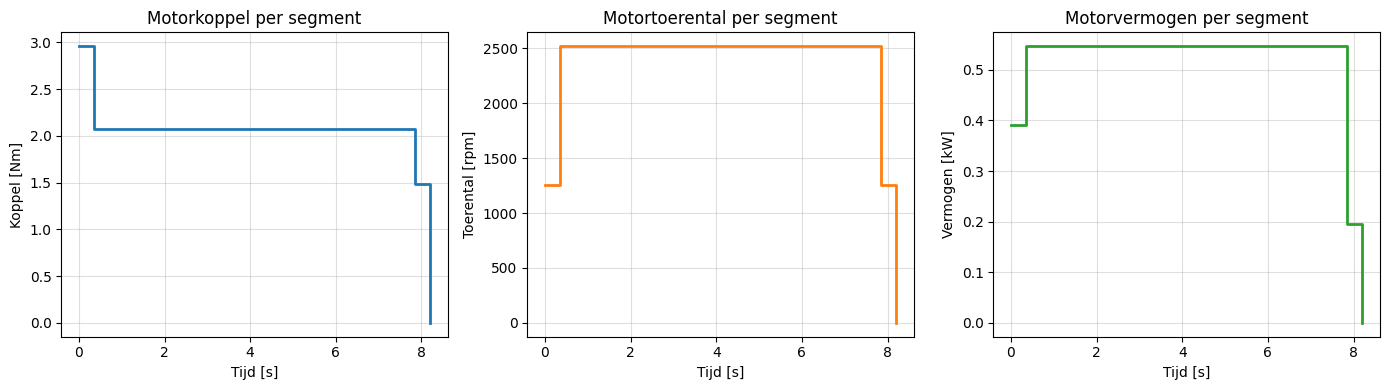

In [29]:
toon_dataframe("profiel motor",   profiel_motor)
toon_dataframe("overzicht motor", overzicht_motor)
toon_dataframe("verdict motor",   verdict_motor)
print("\n=== EISEN MOTOR ===")
print(pd.Series(eisen_motor).to_string())
plot_motorprofiel(profiel_motor)

GESELECTEERDE MOTOR: Panasonic MINAS A6 — MSME082L1H6M (750 W)

Ref: Panasonic MINAS A6 servo catalog (catalogusnr. SX-DSV0600)

Selectiemotivatie:
1. Torque:     T_cont = 2.90 Nm ≥ T_continu_vereist ≈ 2.0 Nm  ✓
               T_piek = 7.16 Nm ≥ T_piek_vereist    ≈ 2.9 Nm  ✓
2. Toerental:  n_max = 5 000 rpm >> n_vereist ≈ 2 772 rpm     ✓
3. Inertie:    J_load/J_rotor = 6.89e-4 / 2.48e-4 = 2.78
               → uitstekende inertie-match (doel: 0.5–3)       ✓
4. Compactheid: 130 mm flens, 2.6 kg                            ✓
5. IP67 + rem, geschikt voor verticale as                       ✓

Vorige selectie MDMF752L1H6M (7.5 kW, J=127×10⁻⁴ kgm²) was sterk overgedimensioneerd:
   - J_load/J_rotor = 6.89e-4 / 127e-4 = 0.054 → rotor domineerde inertie
   - Koppel 25× te hoog voor de werkelijke belasting


In [30]:

gekozen_motor = KandidaatServoMotor(
    fabrikant                    = "Panasonic",
    part_no                      = "MSMF082L1U2M"  ,# MINAS A7, 750W — encoder-compatibel met MCDN205BE,
    naam                         = "MINAS A7 Family Servo Motor (MSMF082L1U2M)",
    rated_output_W               = 750.0,
    rated_torque_Nm              = 2.39,    # bij 3 000 rpm
    continuous_stall_torque_Nm   = 2.90,    # warmtestroom grens
    peak_torque_Nm               = 7.16,    # 3× rated, 1 s max
    rated_speed_rpm              = 3_000.0,
    max_speed_rpm                = 5_000.0,
    rotor_inertia_kgm2           = 2.48e-4, # J_rotor [kgm²]
    recommended_inertia_ratio_max= 30.0,    # Panasonic specificatie
    massa_kg                     = 2.6,
    flange_mm                    = 130.0,
    radial_load_operating_N      = 490.0,
    thrust_load_operating_N      = 196.0,
    shaft_diameter_mm            = 19.0,
    body_diameter_mm             = 95.0,
    body_length_mm               = 155.0,
    holding_brake                = True,
    protection_class             = "IP67",
    shaft_type                   = "keyway",
)

overzicht_kandidaatmotor = maak_kandidaatmotor_overzicht(gekozen_motor, eisen_motor)
verdict_kandidaatmotor   = verifieer_kandidaatmotor(gekozen_motor, eisen_motor)

In [31]:
toon_dataframe("overzicht kandidaatmotor", overzicht_kandidaatmotor)
toon_dataframe("verdict kandidaatmotor",   verdict_kandidaatmotor)
print("\n=== INERTIE-ANALYSE ===")
ir = veilige_del(eisen_motor["J_teruggevoerd_motor_kgm2"], gekozen_motor.rotor_inertia_kgm2)
print(f"  J_load (teruggevoerd)  = {eisen_motor['J_teruggevoerd_motor_kgm2']:.3e} kgm²")
print(f"  J_rotor MSMF082 (A7)       = {gekozen_motor.rotor_inertia_kgm2:.3e} kgm²")
print(f"  J_load / J_rotor      = {ir:.2f}  (doel: 0.5–3)")

n_ok  = int(verdict_kandidaatmotor["geslaagd"].sum())
n_tot = len(verdict_kandidaatmotor)
print(f"\n>>> MOTOR VERIFICATIE: {n_ok}/{n_tot} checks geslaagd")


=== OVERZICHT KANDIDAATMOTOR ===
              grootheid       waarde eenheid
              fabrikant    Panasonic       -
            part number MSMF082L1U2M       -
           rated output         0.75      kW
           rated torque         2.39      Nm
continuous stall torque          2.9      Nm
            peak torque         7.16      Nm
            rated speed       3000.0     rpm
              max speed       5000.0     rpm
          rotor inertia     0.000248    kgm²
       J_load / J_rotor     2.787896       -
  aanbevolen max. ratio         30.0       -
            massa motor          2.6      kg
                 flange        130.0      mm
         shaft diameter         19.0      mm
          body diameter         95.0      mm
            body length        155.0      mm
          holding brake         True       -
       protection class         IP67       -
      vereist toerental       2772.0     rpm
 vereist continu koppel     2.516046      Nm
... (22 rijen in tota

EXPORT

In [32]:
resultaten_motor = {
    "configuratie_motor":      asdict(cfg_motor),
    "eisen_motor":             eisen_motor.copy(),
    "profiel_motor":           profiel_motor.copy(),
    "verdict_motor":           verdict_motor.copy(),
    "overzicht_motor":         overzicht_motor.copy(),
    "kandidaatmotor":          asdict(gekozen_motor),
    "overzicht_kandidaatmotor": overzicht_kandidaatmotor.copy(),
    "verdict_kandidaatmotor":  verdict_kandidaatmotor.copy(),
    "export_voor_volgende_modules": {
        # Motor-eisen (berekend)
        "n_motor_max_rpm":                eisen_motor["n_motor_max_rpm"],
        "toerental_vereist_rpm":          eisen_motor["toerental_vereist_rpm"],
        "koppel_rms_motor_Nm":            eisen_motor["koppel_rms_motor_Nm"],
        "continu_koppel_vereist_Nm":      eisen_motor["continu_koppel_vereist_Nm"],
        "koppel_piek_motor_Nm":           eisen_motor["koppel_piek_motor_Nm"],
        "piek_koppel_vereist_Nm":         eisen_motor["piek_koppel_vereist_Nm"],
        "vermogen_piek_motor_kW":         eisen_motor["vermogen_piek_motor_kW"],
        "J_teruggevoerd_motor_kgm2":      eisen_motor["J_teruggevoerd_motor_kgm2"],
        "inertia_ratio":                  eisen_motor["inertia_ratio"],
        # Geselecteerde motor
        "motor_part_no":                  gekozen_motor.part_no,
        "motor_fabrikant":                gekozen_motor.fabrikant,
        "motor_mass_kg":                  gekozen_motor.massa_kg,
        "motor_max_speed_rpm":            gekozen_motor.max_speed_rpm,
        "motor_continuous_torque_Nm":     gekozen_motor.continuous_stall_torque_Nm,
        "motor_peak_torque_Nm":           gekozen_motor.peak_torque_Nm,
        "motor_rotor_inertia_kgm2":       gekozen_motor.rotor_inertia_kgm2,
        "motor_recommended_inertia_ratio_max": gekozen_motor.recommended_inertia_ratio_max,
        "motor_flange_mm":                gekozen_motor.flange_mm,
        "motor_body_diameter_mm":         gekozen_motor.body_diameter_mm,
        "motor_body_length_mm":           gekozen_motor.body_length_mm,
        "motor_shaft_diameter_mm":        gekozen_motor.shaft_diameter_mm,
        "motor_kandidaat_geslaagd":       bool(verdict_kandidaatmotor["geslaagd"].all()),
    },
}

print("\n=== EXPORT VOOR VOLGENDE MODULES ===")
print(pd.Series(resultaten_motor["export_voor_volgende_modules"]).to_string())


=== EXPORT VOOR VOLGENDE MODULES ===
n_motor_max_rpm                              2520.0
toerental_vereist_rpm                        2772.0
koppel_rms_motor_Nm                        2.096705
continu_koppel_vereist_Nm                  2.516046
koppel_piek_motor_Nm                       2.959768
piek_koppel_vereist_Nm                     3.551722
vermogen_piek_motor_kW                     0.546865
J_teruggevoerd_motor_kgm2                  0.000691
inertia_ratio                              2.787896
motor_part_no                          MSMF082L1U2M
motor_fabrikant                           Panasonic
motor_mass_kg                                   2.6
motor_max_speed_rpm                          5000.0
motor_continuous_torque_Nm                      2.9
motor_peak_torque_Nm                           7.16
motor_rotor_inertia_kgm2                   0.000248
motor_recommended_inertia_ratio_max            30.0
motor_flange_mm                               130.0
motor_body_diameter_mm    